# OAKG — Publication Experiments (real results)

The novelty of this project is the **downstream reasoning layer**, not the segmentation. This notebook
presents the three experiments that support it, each loaded from its committed result file in
`results/` so the numbers never drift. All are CPU, seconds to run.

| | Experiment | Question | Headline |
|---|---|---|---|
| **A2** | Structured retrieval benchmark | Does evidence-calibration (γ) beat imputation on a merged multi-source KG? | γ is decisive: P@10 **0.78 vs 0.08** without it |
| **B1** | Predicted-KG vs GT-KG fidelity | Does an *autonomous* KG answer like a GT KG? | Volume r **0.992**, query Spearman **0.986** |
| **B2** | Self-evolving GT-free validation | Does validation improve as the KG grows? | Joint model **0.78 vs 0.66** marginal, climbs with N |


In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
import os; os.chdir("/home/ud3d4/Desktop/SWOG")
A2 = json.load(open("results/oakg_structured.json"))
B1 = json.load(open("results/kg_fidelity.json"))["summary"]
B2 = json.load(open("results/oakg_evolve.json"))
print("loaded A2, B1, B2 result files")

loaded A2, B1, B2 result files


## A2 — Structured multi-source retrieval benchmark

**Setup.** Merging imaging datasets creates *structural partial-observability*: each source annotated
different organs. We mimic the real merge — patients drawn from single-site "datasets" with **disjoint
observed organs** (Pancreas→pancreas, LiTS→liver, KiTS→kidneys) plus a full-observation FLARE hub — and
sweep the **heterogeneity** (fraction from single-site sources). Ground truth = each patient's true
neighbours on the *full* organ vector. We measure **Precision@10** and the **spurious thin-overlap match
rate** (retrieved patients that share ≤1 organ and aren't true neighbours — the false positive OAKG must
suppress). Baselines: zero/mean-impute, Gower, masked-cosine. **OAKG = masked-cosine × γ**, so
masked-cosine *is* the γ-ablation.

At heterogeneity=0.25 (mixed hub + single-site spokes):
  OAKG (masked×γ)            P@10=0.78   spurious=0.14
  mean-impute                P@10=0.73   spurious=0.17
  zero-impute                P@10=0.71   spurious=0.19
  Gower                      P@10=0.12   spurious=0.48
  masked-cosine = OAKG w/o γ P@10=0.08   spurious=0.84

γ ablation: removing γ changes P@10 0.78 -> 0.08 and spurious 0.14 -> 0.84


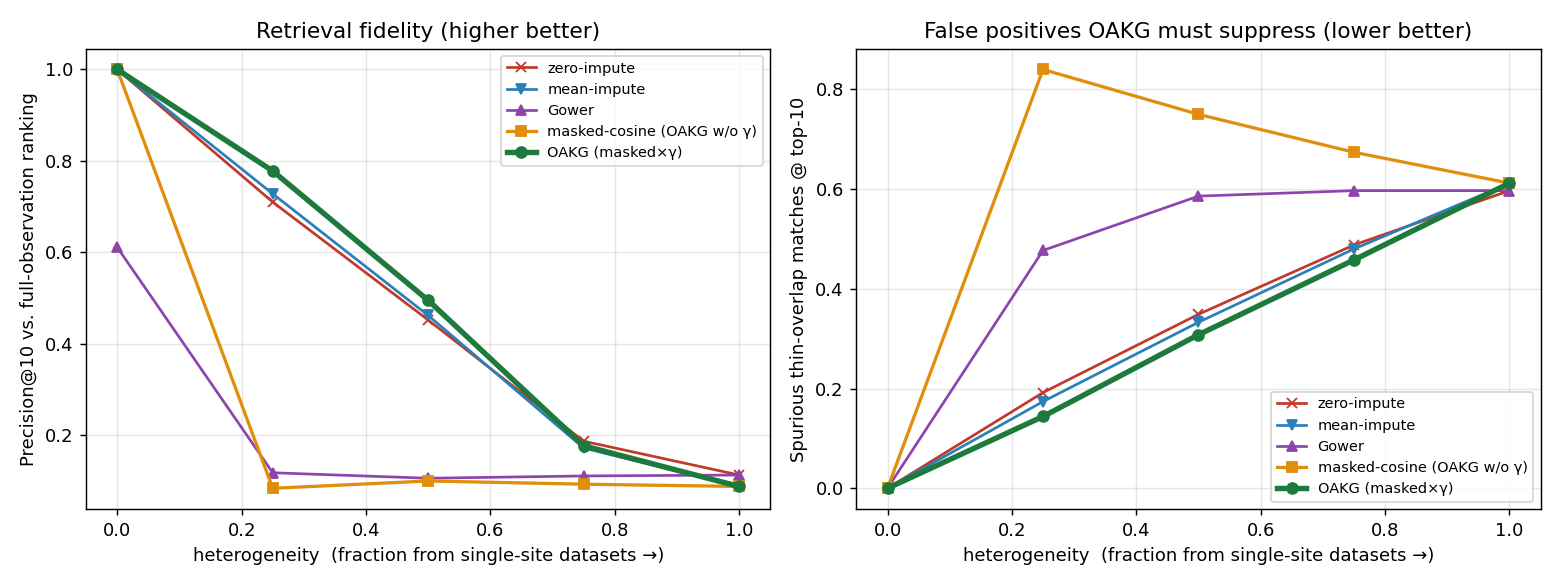

In [2]:
lv = A2["levels"]; cur = A2["curve"]
i = lv.index(0.25)   # the realistic mixed regime
print(f"At heterogeneity={lv[i]} (mixed hub + single-site spokes):")
for m,name in [("oakg","OAKG (masked×γ)"),("mean","mean-impute"),("zero","zero-impute"),
               ("gower","Gower"),("masked","masked-cosine = OAKG w/o γ")]:
    print(f"  {name:26s} P@10={cur[m]['prec'][i]:.2f}   spurious={cur[m]['spur'][i]:.2f}")
print(f"\nγ ablation: removing γ changes P@10 {cur['oakg']['prec'][i]:.2f} -> {cur['masked']['prec'][i]:.2f} "
      f"and spurious {cur['oakg']['spur'][i]:.2f} -> {cur['masked']['spur'][i]:.2f}")
display(Image("results/oakg_structured_fp.png"))

**Finding.** In the realistic mixed regime, **OAKG gives the best retrieval (P@10 0.78) and the
fewest spurious matches (0.14)** — beating every imputation baseline. The **γ ablation is decisive**:
masked-cosine *without* γ collapses to **0.08 / 0.84** — a single shared organ that happens to agree
reads as a perfect match. γ (joint-observability weight) recovers precision **10×** and cuts spurious
matches **6×**. At extreme disjointness (no shared evidence) every method hits the floor — OAKG returns
it honestly instead of fabricating a signal, which imputation does. *This is the core method result.*

## B1 — Predicted-KG vs GT-KG answer fidelity

**Setup.** Does the KG built from **autonomous, label-free** masks answer like one built from ground
truth? On **20 paired pancreas cases** (GT mask + prediction, identical geometry) we derive the exact
phenotypes the KG stores (volume, max-diameter, centroid, size-bin) from *both* masks and compare at the
node, categorical, and query levels.

cases=20  mean Dice=0.919
  volume    MAPE 4.8%   r=0.992
  diameter  MAPE 0.9%   r=0.997
  centroid  1.4 mm
  size-bin agreement   0.95
  'rank by size' query  Spearman 0.986  top3-overlap 1.0


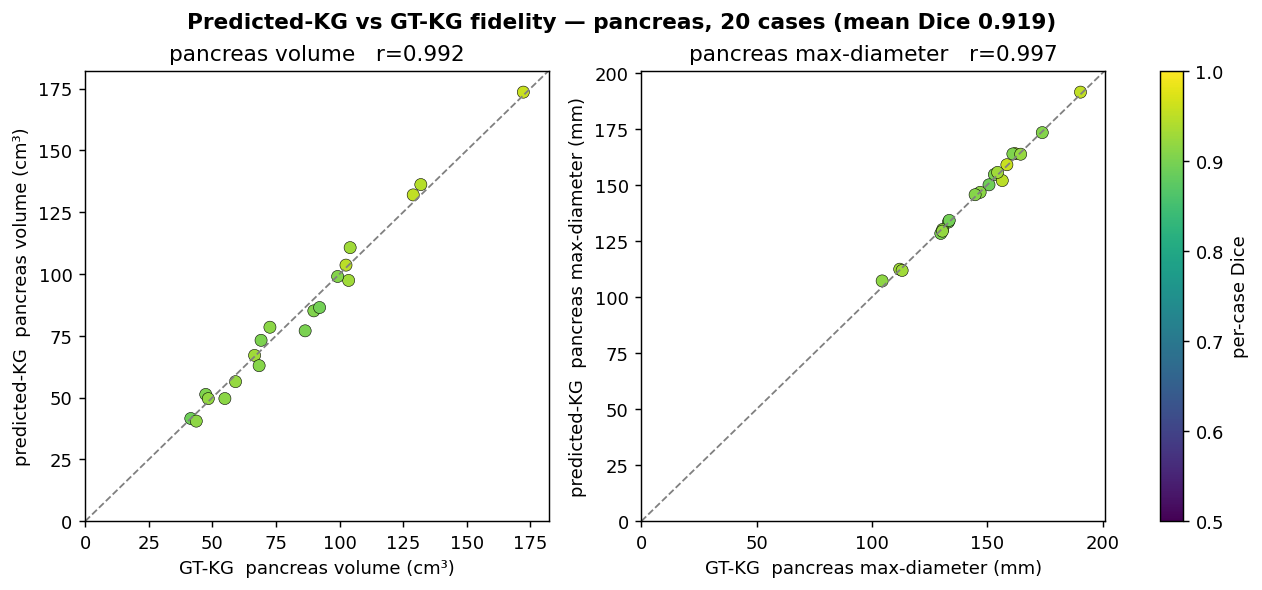

In [3]:
nf = B1["node_fidelity"]; qr = B1["query_rank_by_size"]
print(f"cases={B1['n_cases']}  mean Dice={B1['mean_dice']}")
print(f"  volume    MAPE {nf['volume_MAPE_%']}%   r={nf['volume_pearson_r']}")
print(f"  diameter  MAPE {nf['diameter_MAPE_%']}%   r={nf['diameter_pearson_r']}")
print(f"  centroid  {nf['centroid_mean_mm']} mm")
print(f"  size-bin agreement   {B1['categorical_size_bin_agreement']}")
print(f"  'rank by size' query  Spearman {qr['spearman']}  top3-overlap {qr['top3_overlap']}")
display(Image("results/kg_fidelity.png"))

**Finding.** At mean Dice **0.919** the predicted KG matches the GT KG almost exactly — volume
within **4.8%** (r=0.992), diameter within 0.9%, centroid within **1.4 mm**, **95%** size-bin agreement,
and the "largest pancreas" query is preserved (**Spearman 0.986**, top-3 identical). *Honest caveat:*
these are well-segmented cases, so the takeaway is precise — **segmentation quality, not KG construction,
is the bottleneck**; fidelity scales with Dice.

## B2 — Self-evolving GT-free validation

**Setup.** Can the KG validate a **new, unlabeled** patient with no ground truth, and does it get better
as it admits patients? We plant realistic segmentation errors (a volume leak that breaks the
volume↔diameter relation) and grow the reference cohort N=15→1083. Two plausibility models: **marginal**
(per-organ z-score) vs the KG's **joint** model (cohort covariance / Mahalanobis over 5 organs ×
{log-volume, log-diameter}). Metric = clean-vs-error AUROC.

N       marginal   JOINT(Mahalanobis)
   15    0.642      0.744
   30    0.653      0.771
   60    0.660      0.782
  120    0.663      0.788
  240    0.661      0.788
  480    0.659      0.785
  960    0.655      0.782
 1083    0.655      0.781

joint beats marginal by ~0.12 AUROC everywhere;
joint climbs 0.744 -> 0.788 as the KG grows, then plateaus.


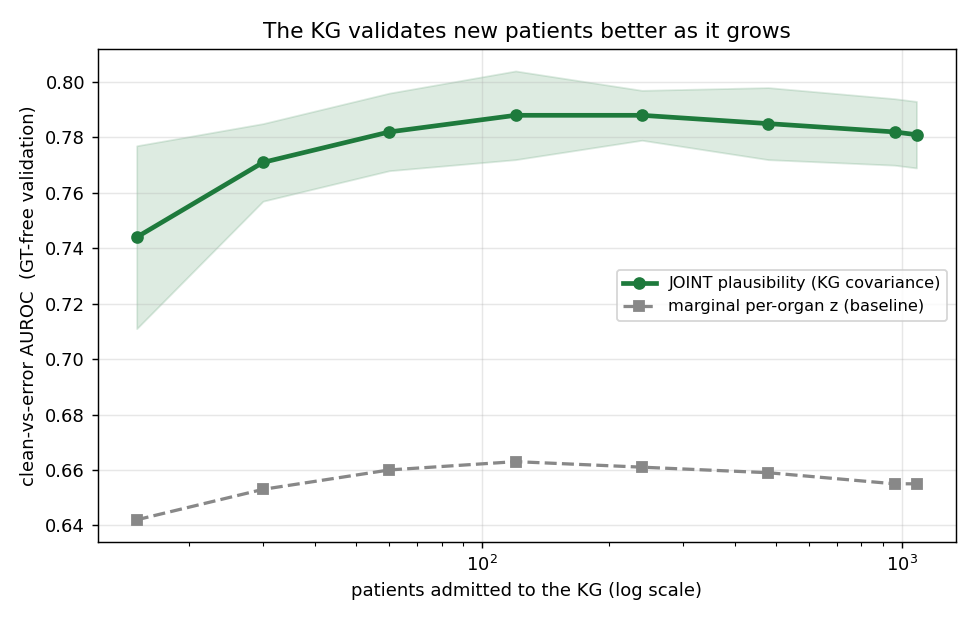

In [4]:
sz = B2["sizes"]
print("N       marginal   JOINT(Mahalanobis)")
for i,s in enumerate(sz):
    print(f"{s:5d}    {B2['marginal'][i]:.3f}      {B2['joint'][i]:.3f}")
print(f"\njoint beats marginal by ~{np.mean(np.array(B2['joint'])-np.array(B2['marginal'])):.2f} AUROC everywhere;")
print(f"joint climbs {B2['joint'][0]:.3f} -> {max(B2['joint']):.3f} as the KG grows, then plateaus.")
display(Image("results/oakg_evolve.png"))

**Finding.** The KG's **joint** validation beats a marginal per-organ check by **+0.12 AUROC**
(0.78 vs 0.66) — it catches the volume↔diameter inconsistency the marginal check can't see — and it
**improves as the KG grows** (0.74→0.79 over N=15→120), then plateaus once the 10-D covariance is
well-estimated. The marginal baseline stays flat. *Accumulating patients doesn't sharpen a mean — it
sharpens the joint phenotype model, which is exactly what a growing KG accumulates.* Richer phenotypes
(13 organs + tumor) would extend the climb.

## Summary — what the experiments establish

- **A2** — the OAKG contribution is real and *specifically* due to γ: on a merged multi-source KG,
  evidence-calibration eliminates the false positives that imputation and naive masked-similarity create.
- **B1** — the autonomous, label-free pipeline yields a KG faithful to the GT KG (queries preserved);
  the remaining error is inherited from segmentation, not introduced by the KG.
- **B2** — the KG validates new unlabeled patients GT-free, and the joint model it accumulates makes that
  validation improve as the graph grows — the self-evolving property.

**Pending:** **C** (autonomous per-structure Dice sweep vs the semi-oracle ceiling, vs K-Prism /
GF-Screen / PanTS) — GPU-bound. Scripts: `exp_oakg_structured.py`, `exp_kg_fidelity.py`,
`exp_oakg_evolve.py`.